In [ ]:
import cv2
import numpy as np
from skimage.feature import local_binary_pattern

def extract_features(image_path):

    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = []

    lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    features.append(lap_var)

    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size
    features.append(edge_density)

    glare_ratio = np.sum(gray > 240) / gray.size
    features.append(glare_ratio)

    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)

    magnitude = np.abs(fshift)

    h, w = magnitude.shape
    center_h, center_w = h // 2, w // 2

    radius = min(h, w) // 8

    mask = np.ones_like(magnitude)
    mask[center_h-radius:center_h+radius,
         center_w-radius:center_w+radius] = 0

    high_freq_energy = np.mean(magnitude * mask)
    features.append(high_freq_energy)

    lbp = local_binary_pattern(
        gray,
        P=8,
        R=1,
        method="uniform"
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, 11),
        density=True
    )

    features.extend(hist)

    return np.array(features)

In [2]:
import os

X = []
y = []

dataset_path = "dataset"

for label, folder in enumerate(["real", "screen"]):

    folder_path = os.path.join(dataset_path, folder)

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)

        try:
            feats = extract_features(img_path)

            X.append(feats)
            y.append(label)

        except:
            pass

X = np.array(X)
y = np.array(y)

print(X.shape)

(322, 14)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

acc = accuracy_score(y_test, preds)

print("Accuracy:", acc * 100)

Accuracy: 90.76923076923077


In [15]:
def predict_image(path):

    feats = extract_features(path).reshape(1, -1)

    prob = model.predict_proba(feats)[0][1]

    print("Screen Score:", prob)

    if prob > 0.5:
        print("Prediction: SCREEN")
    else:
        print("Prediction: REAL")

predict_image("C:\\Users\\TVM2\\OneDrive\\Documents\\caughtuai\\train\\real\\0654.jpg")

Screen Score: 0.23250386
Prediction: REAL


In [ ]:
import joblib

joblib.dump(model, "xgboost_screen_detector.pkl")

print("Model saved successfully!")

Model saved successfully!


In [53]:
def predict_image(path):

    feats = extract_features(path).reshape(1, -1)

    prob = model.predict_proba(feats)[0][1]

    print("Screen Score:", prob)

    if prob > 0.5:
        print("Prediction: SCREEN")
    else:
        print("Prediction: REAL")

predict_image("imp.jpeg")

Screen Score: 0.6578958
Prediction: SCREEN


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

eff_model = models.efficientnet_b0(weights=None)

in_features = eff_model.classifier[1].in_features

eff_model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, 2)
)

eff_model.load_state_dict(
    torch.load("best_efficientnet.pth", map_location=device)
)

eff_model = eff_model.to(device)
eff_model.eval()

print("EfficientNet loaded!")

C:\Users\TVM2\AppData\Local\Temp\ipykernel_20988\3355651803.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("best_efficientnet.pth", map_location=device)


EfficientNet loaded!


In [20]:
import joblib

xgb_model = joblib.load("xgboost_screen_detector.pkl")

print("XGBoost model loaded!")

XGBoost model loaded!


In [22]:
from torchvision import transforms

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

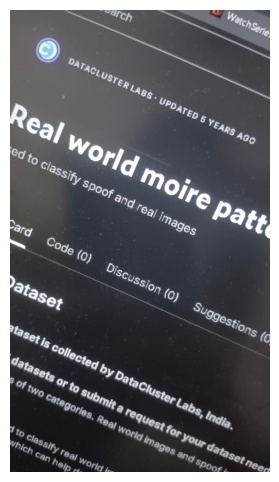

EfficientNet Score : 0.9036
XGBoost Score      : 0.6217
Final Score        : 0.7908
Prediction         : SCREEN


0.7908189177513122

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def ensemble_predict(img_path):

    image = Image.open(img_path).convert("RGB")

    x = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = eff_model(x)
        eff_score = torch.softmax(output, dim=1)[0][1].item()

    feats = extract_features(img_path).reshape(1, -1)
    xgb_score = xgb_model.predict_proba(feats)[0][1]

    final_score = 0.6 * eff_score + 0.4 * xgb_score

    prediction = "SCREEN" if final_score > 0.5 else "REAL"

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print(f"EfficientNet Score : {eff_score:.4f}")
    print(f"XGBoost Score      : {xgb_score:.4f}")
    print(f"Final Score        : {final_score:.4f}")
    print(f"Prediction         : {prediction}")

    return final_score

ensemble_predict("st2.jpeg")

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import torch

classes = ['real', 'screen']

def ensemble_predict(img_path,
                     eff_weight=0.6,
                     xgb_weight=0.4):


    image = Image.open(img_path).convert("RGB")

    x = val_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(x)
        eff_probs = torch.softmax(output, dim=1)

    eff_score = eff_probs[0][1].item()  

  
    feats = extract_features(img_path).reshape(1, -1)

    xgb_score = xgboost_screen_detector.predict_proba(feats)[0][1]


    final_score = (
        eff_weight * eff_score +
        xgb_weight * xgb_score
    )

    pred = "screen" if final_score > 0.5 else "real"

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print(f"EfficientNet Score : {eff_score:.4f}")
    print(f"XGBoost Score      : {xgb_score:.4f}")
    print(f"Final Score        : {final_score:.4f}")
    print(f"Prediction         : {pred.upper()}")

    return final_score

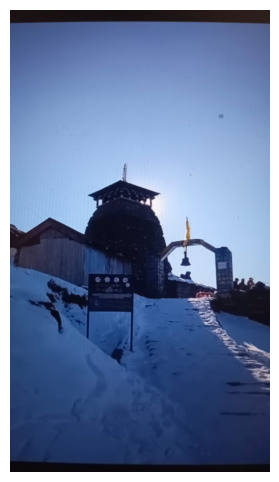

EfficientNet Score : 0.3227
XGBoost Score      : 0.7978
Final Score        : 0.5127
Prediction         : SCREEN


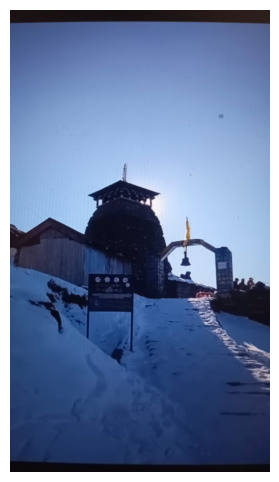

EfficientNet Score : 0.3227
XGBoost Score      : 0.7978
Final Score        : 0.5127
Prediction         : SCREEN


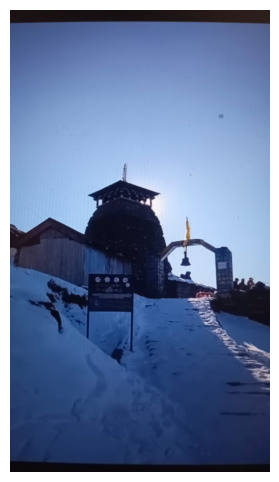

EfficientNet Score : 0.3227
XGBoost Score      : 0.7978
Final Score        : 0.5127
Prediction         : SCREEN


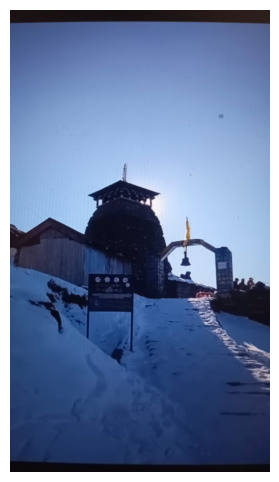

EfficientNet Score : 0.3227
XGBoost Score      : 0.7978
Final Score        : 0.5127
Prediction         : SCREEN


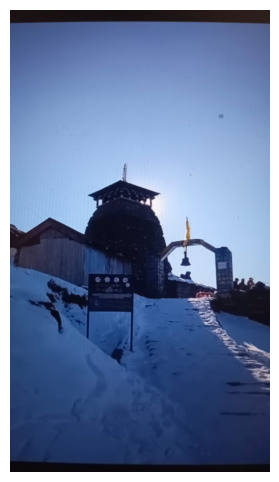

EfficientNet Score : 0.3227
XGBoost Score      : 0.7978
Final Score        : 0.5127
Prediction         : SCREEN


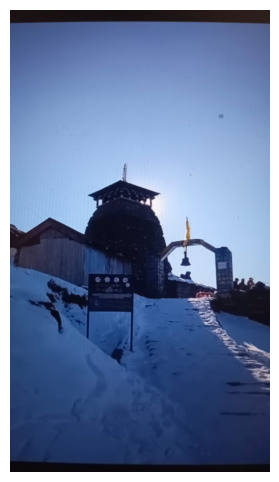

EfficientNet Score : 0.3227
XGBoost Score      : 0.7978
Final Score        : 0.5127
Prediction         : SCREEN

Latency: 675.55 ms


In [ ]:
import time

img_path = "screen.jpeg"

for _ in range(5):
    ensemble_predict(img_path)

start = time.perf_counter()

ensemble_predict(img_path)

end = time.perf_counter()

latency_ms = (end - start) * 1000

print(f"\nLatency: {latency_ms:.2f} ms")

In [30]:
times = []

for _ in range(100):
    image = Image.open("screen.jpeg").convert("RGB")
    x = val_transform(image).unsqueeze(0).to(device)

    start = time.perf_counter()

    with torch.no_grad():
        output = eff_model(x)

    end = time.perf_counter()
    times.append((end-start)*1000)

print(np.mean(times))

18.200980999945386


In [ ]:
def predict_xgb(img_path):

    feats = extract_features(img_path).reshape(1, -1)

    screen_prob = xgb_model.predict_proba(feats)[0][1]

    prediction = "SCREEN" if screen_prob > 0.5 else "REAL"

    print(f"Screen Score : {screen_prob:.4f}")
    print(f"Prediction   : {prediction}")

    return screen_prob

In [52]:
predict_xgb("st2.jpeg")

Screen Score : 0.6217
Prediction   : SCREEN


0.6216871